# imports & setup

In [ ]:
from pathlib import Path
from typing import Any, Literal, Sequence
import itertools

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors
from tqdm import tqdm

# scipy
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
import sklearn.base
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import parse_cls, DistanceTensorResult
from attention_motifs.features.head_analysis import create_embedding_df_multi, plot_head_embeddings_multi
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [ ]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# load dists

In [ ]:
# load head distances
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read(
	PATH_BASE / "features" / "head_dists.zanj"
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
# load attentionpedia
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

[ <ipykernel>:4 ] HEAD_DISTS.distances: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64
[ <ipykernel>:5 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


array([[ 0.        ,  8.69202432,  9.54040428, ..., 12.25940865,
        12.16375817, 12.23178058],
       [ 8.69202432,  0.        ,  9.8659314 , ...,  9.98180279,
         9.99545272,  9.95879912],
       [ 9.54040428,  9.8659314 ,  0.        , ...,  8.9271944 ,
         8.64037894,  8.91942945],
       ...,
       [12.25940865,  9.98180279,  8.9271944 , ...,  0.        ,
         1.75838832,  1.64093945],
       [12.16375817,  9.99545272,  8.64037894, ...,  1.75838832,
         0.        ,  1.69310037],
       [12.23178058,  9.95879912,  8.91942945, ...,  1.64093945,
         1.69310037,  0.        ]])

# head projection & clustering

In [ ]:


HEAD_EMBED_DF: pl.DataFrame = create_embedding_df_multi(
	head_dists=HEAD_DISTS,
	attnpedia=ATTENTIONPEDIA,
	embedding_methods=["isomap", "umap", "tsne", "pca"],
	n_components_list=[2],
	n_neighbors_list=[2, 4, 8, 16, 32, 64],
	match_model=None,
	save_path=PATH_BASE / "head_embed",
)

  0%|          | 0/24 [00:00<?, ?it/s]/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
100%|██████████| 24/24 [00:34<00:00,  1.44s/it]


/tmp/ipykernel_85491/2142398445.py:169: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap("tab10", len(categories))
/tmp/ipykernel_85491/2142398445.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap: matplotlib.colors.Colormap = plt.cm.get_cmap("tab10", len(categories))


Found methods: ['isomap', 'umap', 'tsne']
Found n_neighbors: [2, 4, 8, 16, 32, 64]
Using n_components: 2
Using model: ALL


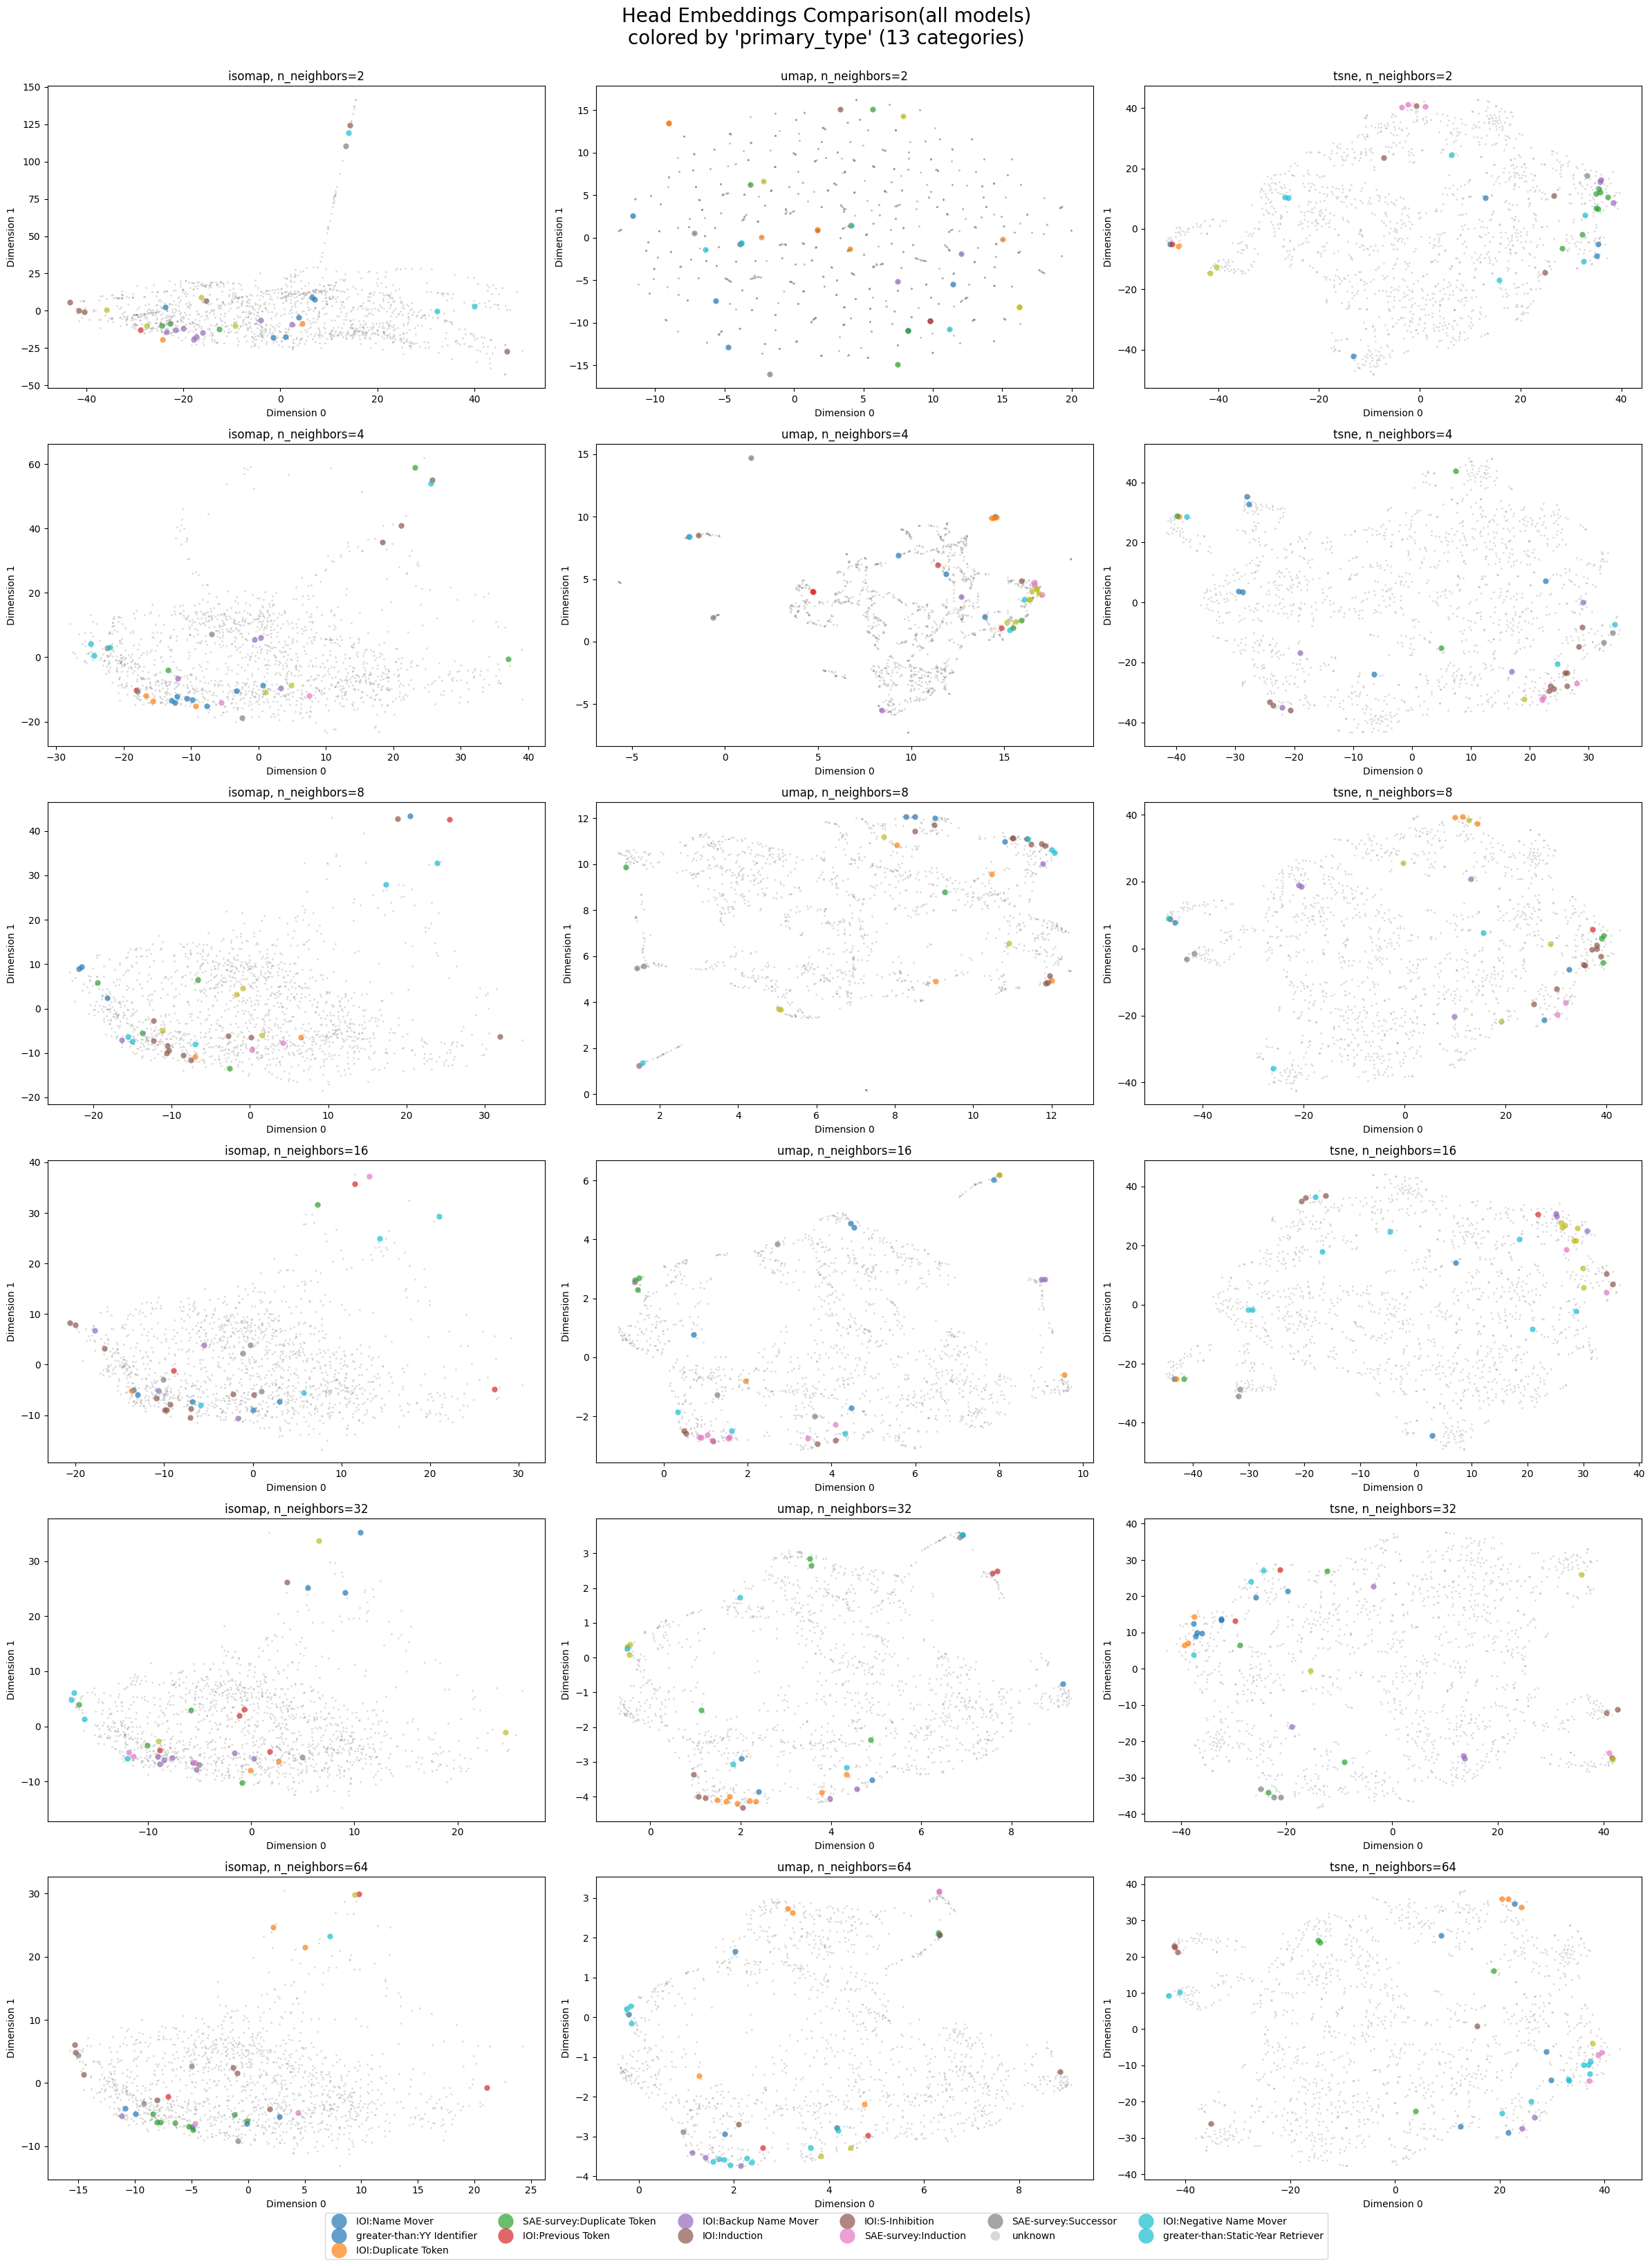

In [ ]:

_ = plot_head_embeddings_multi(
	HEAD_EMBED_DF,
	methods=["isomap", "umap", "tsne"],
	sizes=(6, 2),
	figsize=(24, 32),
)
plt.savefig("figures/head_embed.all.pdf", bbox_inches="tight")